# 单条光谱离线处理过程展示

这个 notebook 对照当前 `raman.data` 的真实实现，展示单条光谱在离线阶段的处理顺序：

1. 读取原始光谱
2. 按当前配置做单谱宇宙射线尖峰去除
3. 使用 AsLS 做基线校正（拟合时跳过 `bad_bands`）
4. 按配置裁剪波段
5. 在裁剪后的原始点上先删除 `bad_bands`
6. 只在有效目标波数坐标上插值
7. 用库函数 `preprocess_single_spectrum` 复核结果
8. 展示 `smooth` 通道的构建过程
9. 展示主通道默认使用的 `SNV` 标准化

注意：`python -m raman.data train` 会先生成可复用的 `train_raw` 清洗中间层，`train_raw` 和 `test` 落盘保存的是删除坏波段后、已在有效目标轴上对齐的光谱，
不是 SNV 后的结果；SNV 主要用于模型输入和绘图展示，而不是离线落盘值。

完整目标轴点数由 `cfg.target_points` 决定，有效目标轴点数由 `bad_bands` 决定，运行第一个代码单元会直接打印当前配置。
这与裁剪后原始采样点数不同；原始点数来自仪器采样轴，目标轴点数来自统一插值参考轴。


In [58]:
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Microsoft YaHei'
import numpy as np
import torch
import torch.nn.functional as F
import seaborn as sns

def find_project_root(start=None):
    """从当前目录向上查找项目根目录，兼容从 notebooks/ 里启动的情况"""
    current = Path(start or Path.cwd()).resolve()
    for path in (current, *current.parents):
        if (path / "raman").is_dir() and (path / "dataset").is_dir():
            return path
    return current


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from raman.data.profiles import get_dataset_dir, get_profile
from raman.data.offline import asls_baseline, preprocess_single_spectrum, remove_cosmic_rays
from raman.data.spectrum import (
    build_valid_mask,
    minmax_normalize,
    read_arc_data,
    snv,
)
from raman.data.build import COMMON_BAD_BANDS, DEFAULT_PIPELINE_CONFIG
from raman.config import Config
from raman.data.input import build_sg_kernels, normalize_spectrum

sns.set_theme(style="whitegrid", context="talk", font="Microsoft YaHei")
plt.rcParams["figure.figsize"] = (10, 5)

DATASET_NAME = "细菌"
profile = get_profile(DATASET_NAME)  # 也可改成中文别名，例如 "细菌"
dataset_dir = get_dataset_dir(profile, PROJECT_ROOT)
cfg = DEFAULT_PIPELINE_CONFIG
train_cfg = Config()
train_cfg.dataset_name = profile.dataset_name
BAD_BANDS = COMMON_BAD_BANDS
WN_REF = cfg.build_wn_ref()
COSMIC_RAY_REMOVE = profile.profile_id in set(cfg.cosmic_ray_enabled_profile_ids)
COSMIC_RAY_OPTIONS = dict(
    cosmic_ray_remove=COSMIC_RAY_REMOVE,
    cosmic_ray_window=cfg.cosmic_ray_window,
    cosmic_ray_threshold=cfg.cosmic_ray_threshold,
    cosmic_ray_max_iter=cfg.cosmic_ray_max_iter,
)
SAMPLE_SEED = None  # 设为整数可复现抽样；设为 None 则每次随机挑一条。


def pick_sample_path(dataset_dir, profile, sample_seed=None):
    """按目录优先级随机选一条样本；可通过 sample_seed 固定抽样结果。"""
    candidate_roots = [
        dataset_dir / profile.root_process_raw,
        dataset_dir / profile.root_init,
        dataset_dir / profile.root_train_clean,
        dataset_dir / profile.root_test_raw,
        dataset_dir / profile.root_test_clean,
    ]
    rng = random.Random(sample_seed)
    for root in candidate_roots:
        if not root.is_dir():
            continue
        matches = sorted(root.rglob("*.arc_data"))
        if matches:
            return rng.choice(matches)
    raise FileNotFoundError("未找到可展示的 .arc_data 文件，请先准备 train_raw 或 init")


def add_bad_band_spans(ax, bad_bands, label="bad bands"):
    if getattr(ax, "_bad_band_spans_added", False):
        return
    for i, (band_min, band_max) in enumerate(bad_bands):
        ax.axvspan(
            band_min,
            band_max,
            color="gray",
            alpha=0.15,
            label=label if i == 0 else None,
        )
    ax._bad_band_spans_added = True


def plot_without_bad_bands(ax, wn, sp, bad_bands, **kwargs):
    """绘图时让坏段断线，只保留灰色 mask，不展示坏段内数据"""
    sp_plot = np.asarray(sp, dtype=np.float32).copy()
    keep_mask = build_valid_mask(np.asarray(wn), bad_bands)
    if keep_mask is not None:
        sp_plot[~keep_mask] = np.nan
    return ax.plot(wn, sp_plot, **kwargs)


def plot_disconnected_axis(ax, wn, sp, gap_factor=3.0, **kwargs):
    """已经删除坏段后的光谱按波数间隔断线，避免跨缺口连线"""
    wn = np.asarray(wn)
    sp_plot = np.asarray(sp, dtype=np.float32).copy()
    if wn.size > 2:
        diffs = np.diff(wn)
        normal_step = np.median(diffs[diffs > 0]) if np.any(diffs > 0) else 0
        if normal_step > 0:
            gap_idx = np.where(diffs > normal_step * gap_factor)[0]
            sp_plot[gap_idx] = np.nan
    return ax.plot(wn, sp_plot, **kwargs)


def plot_processed_with_mask(ax, wn, sp, **kwargs):
    """统一绘制已删除坏段后的光谱：断线、显示 mask、固定裁剪范围"""
    line = plot_disconnected_axis(ax, wn, sp, **kwargs)
    add_bad_band_spans(ax, BAD_BANDS)
    ax.set_xlim([cfg.cut_min, cfg.cut_max])
    return line


sample_path = pick_sample_path(dataset_dir, profile, sample_seed=SAMPLE_SEED)
print(f"project_root = {PROJECT_ROOT}")
print(f"dataset_dir = {dataset_dir}")
print(f"sample_path = {sample_path}")
print(f"sample_seed = {SAMPLE_SEED}")
print(f"cut range = [{cfg.cut_min}, {cfg.cut_max}]")
print(f"target_points = {cfg.target_points}")
print(f"bad_bands = {BAD_BANDS}")
print(f"cosmic_ray_remove = {COSMIC_RAY_REMOVE}")
print(f"cosmic_ray_threshold = {cfg.cosmic_ray_threshold}")


project_root = E:\Pythonproject\拉曼光谱分类
dataset_dir = E:\Pythonproject\拉曼光谱分类\dataset\细菌
sample_path = E:\Pythonproject\拉曼光谱分类\dataset\细菌\init\Staphylococcus\SEPI04\cell15_Area01_001_shift.arc_data
sample_seed = None
cut range = [600, 1800]
target_points = 896
bad_bands = ((890.0, 950.0),)
cosmic_ray_remove = True
cosmic_ray_threshold = 7.0


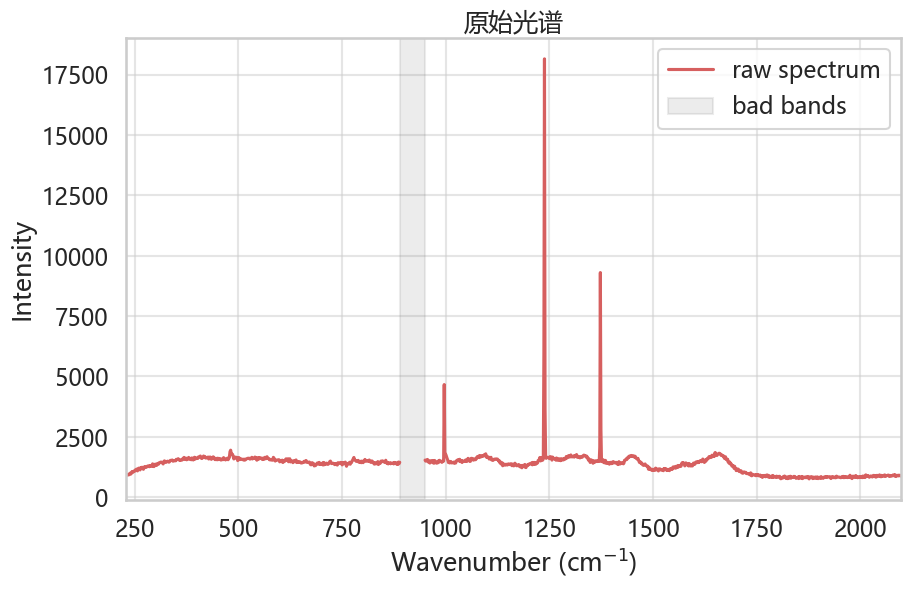

原始点数: 1340
原始波数范围: 229.63 -> 2098.08


In [59]:
# 1. 读取原始光谱
wn, sp = read_arc_data(sample_path)
if wn.size == 0 or sp.size == 0:
    raise ValueError(f"读取失败：{sample_path}")

fig, ax = plt.subplots(figsize=(10, 6))
plot_without_bad_bands(ax, wn, sp, BAD_BANDS, color=sns.color_palette("muted")[3], label="raw spectrum")
add_bad_band_spans(ax, BAD_BANDS)
ax.set_xlim([wn.min(), wn.max()])
ax.set_title("原始光谱")
ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Intensity")
ax.legend()
plt.show()

print(f"原始点数: {wn.size}")
print(f"原始波数范围: {wn.min():.2f} -> {wn.max():.2f}")


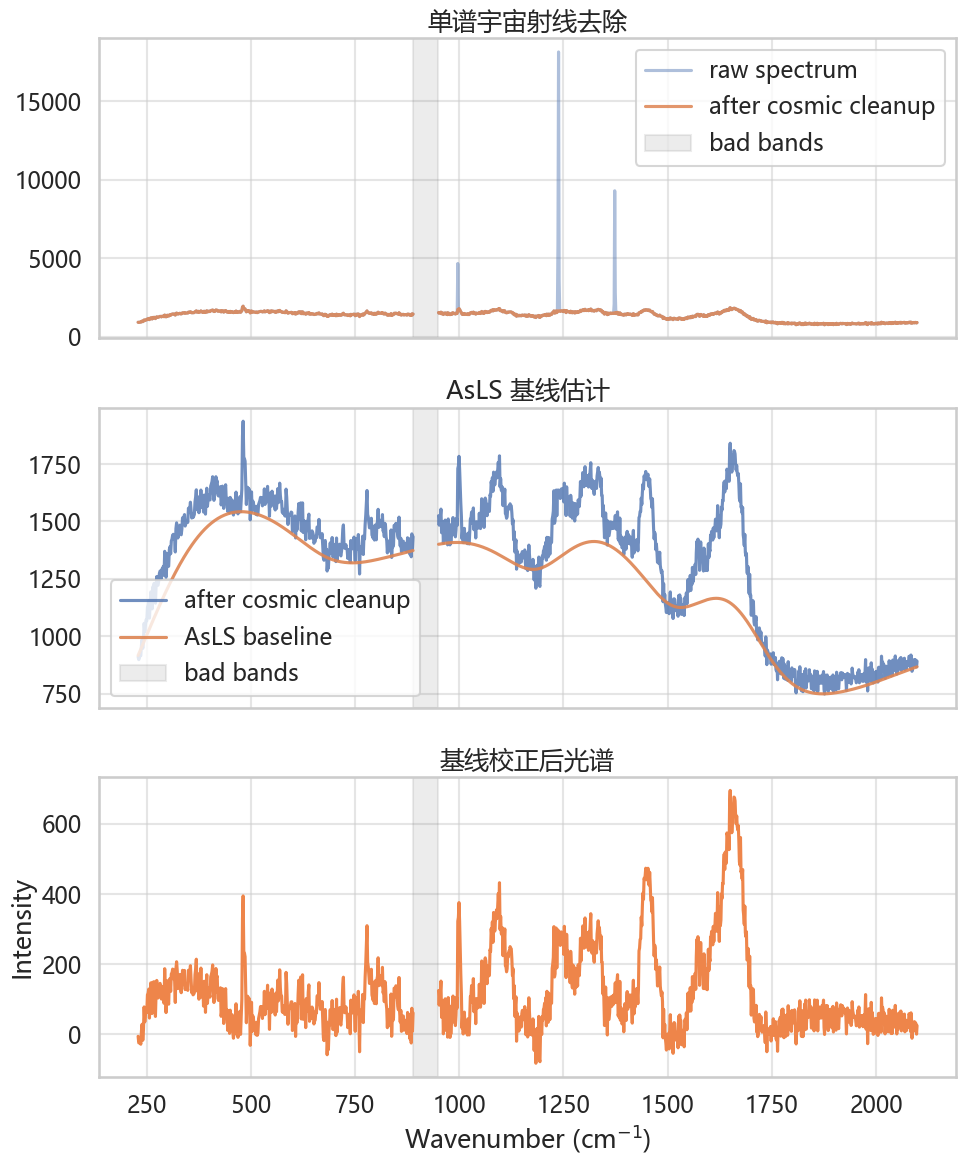

单谱宇宙射线替换点数: 7


In [60]:
# 2. 单谱宇宙射线尖峰去除，再做 AsLS 基线校正
valid_mask_raw = build_valid_mask(wn, BAD_BANDS)
if COSMIC_RAY_REMOVE:
    sp_cosmic, cosmic_replaced = remove_cosmic_rays(
        sp,
        window=cfg.cosmic_ray_window,
        threshold=cfg.cosmic_ray_threshold,
        max_iter=cfg.cosmic_ray_max_iter,
        valid_mask=valid_mask_raw,
    )
else:
    sp_cosmic = np.asarray(sp, dtype=np.float32)
    cosmic_replaced = 0

baseline = asls_baseline(
    sp_cosmic,
    lam=cfg.asls_lam,
    p=cfg.asls_p,
    niter=cfg.asls_max_iter,
    valid_mask=valid_mask_raw,
)
sp_bc = sp_cosmic - baseline

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
plot_without_bad_bands(axes[0], wn, sp, BAD_BANDS, label="raw spectrum", alpha=0.45)
plot_without_bad_bands(axes[0], wn, sp_cosmic, BAD_BANDS, label="after cosmic cleanup", alpha=0.85)
add_bad_band_spans(axes[0], BAD_BANDS)
axes[0].set_title("单谱宇宙射线去除")
axes[0].legend()

plot_without_bad_bands(axes[1], wn, sp_cosmic, BAD_BANDS, label="after cosmic cleanup", alpha=0.8)
plot_without_bad_bands(axes[1], wn, baseline, BAD_BANDS, label="AsLS baseline", alpha=0.9)
add_bad_band_spans(axes[1], BAD_BANDS)
axes[1].set_title("AsLS 基线估计")
axes[1].legend()

plot_without_bad_bands(axes[2], wn, sp_bc, BAD_BANDS, color=sns.color_palette("muted")[1])
add_bad_band_spans(axes[2], BAD_BANDS)
axes[2].set_title("基线校正后光谱")
axes[2].set_xlabel("Wavenumber (cm$^{-1}$)")
axes[2].set_ylabel("Intensity")
plt.tight_layout()
plt.show()

print(f"单谱宇宙射线替换点数: {cosmic_replaced}")


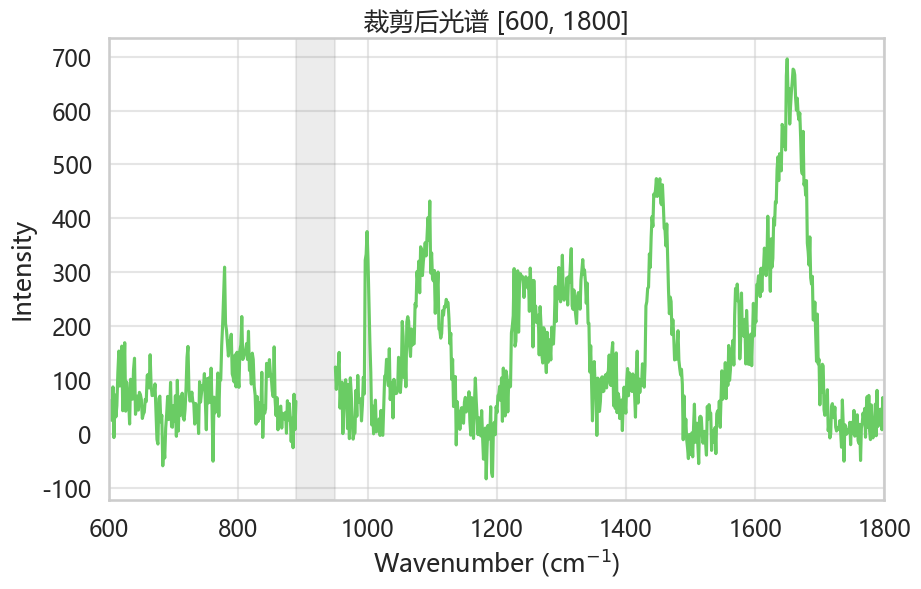

裁剪后点数: 861
裁剪后波数范围: 601.28 -> 1799.15


In [61]:
# 4. 按当前配置裁剪波段
mask_cut = (wn >= cfg.cut_min) & (wn <= cfg.cut_max)
wn_cut = wn[mask_cut]
sp_cut = sp_bc[mask_cut]

fig, ax = plt.subplots(figsize=(10, 6))
plot_without_bad_bands(ax, wn_cut, sp_cut, BAD_BANDS, color=sns.color_palette("muted")[2])
add_bad_band_spans(ax, BAD_BANDS)
ax.set_xlim([cfg.cut_min, cfg.cut_max])
ax.set_title(f"裁剪后光谱 [{cfg.cut_min}, {cfg.cut_max}]")
ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Intensity")
plt.show()

print(f"裁剪后点数: {wn_cut.size}")
print(f"裁剪后波数范围: {wn_cut[0]:.2f} -> {wn_cut[-1]:.2f}")


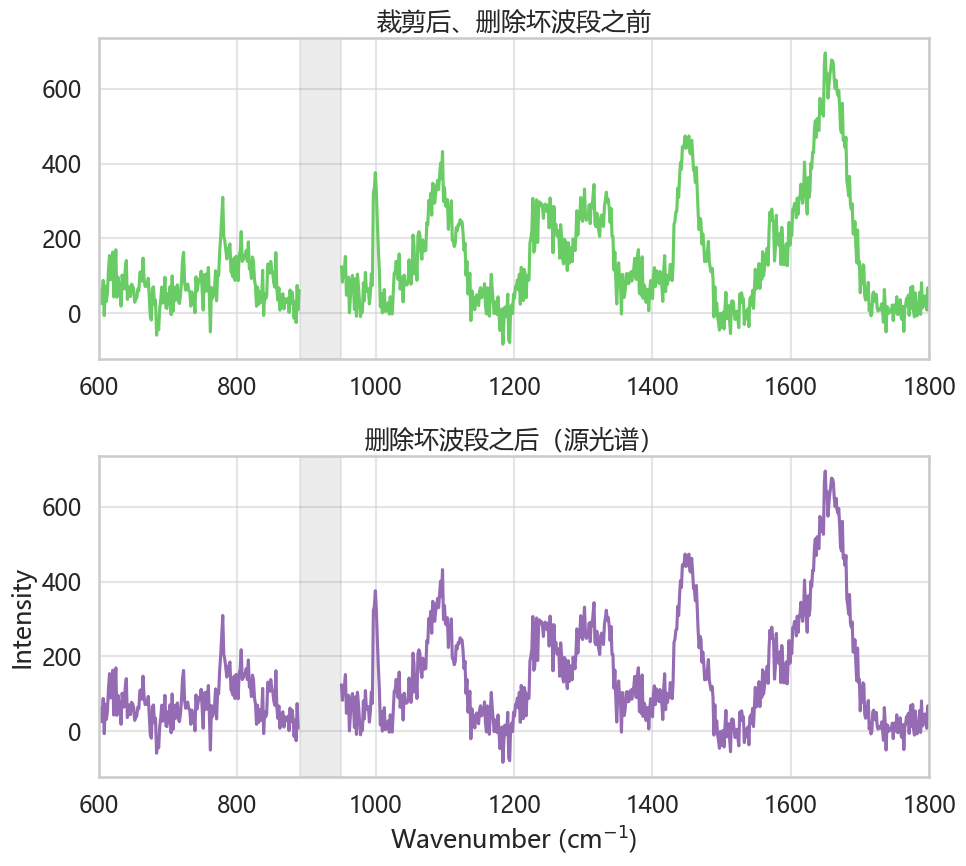

删除坏波段后点数: 820
删除点数: 41


In [62]:
# 5. 在裁剪结果上先删除坏波段
# 当前 raman.data 的真实做法是让坏波段同时退出插值与最终输出。
src_keep_mask = build_valid_mask(wn_cut, BAD_BANDS)
if src_keep_mask is None:
    src_keep_mask = np.ones_like(wn_cut, dtype=bool)

wn_valid = wn_cut[src_keep_mask]
sp_valid = sp_cut[src_keep_mask]

fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=False)
plot_without_bad_bands(axes[0], wn_cut, sp_cut, BAD_BANDS, color=sns.color_palette("muted")[2])
add_bad_band_spans(axes[0], BAD_BANDS)
axes[0].set_xlim([cfg.cut_min, cfg.cut_max])
axes[0].set_title("裁剪后、删除坏波段之前")

plot_processed_with_mask(axes[1], wn_valid, sp_valid, color=sns.color_palette("muted")[4])
axes[1].set_title("删除坏波段之后（源光谱）")
axes[1].set_xlabel("Wavenumber (cm$^{-1}$)")
axes[1].set_ylabel("Intensity")
plt.tight_layout()
plt.show()

print(f"删除坏波段后点数: {sp_valid.shape[0]}")
print(f"删除点数: {(~src_keep_mask).sum()}")


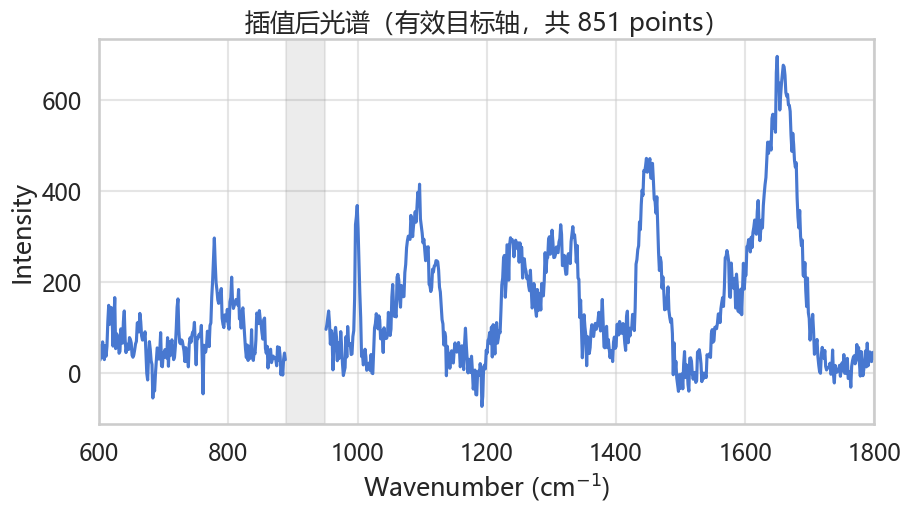

完整目标轴点数: 896
有效目标轴点数: 851


In [63]:
# 6. 只在保留后的目标波数坐标上插值
target_keep_mask = build_valid_mask(WN_REF, BAD_BANDS)
if target_keep_mask is None:
    target_keep_mask = np.ones_like(WN_REF, dtype=bool)

wn_processed = WN_REF[target_keep_mask]
sp_processed = np.interp(wn_processed, wn_valid, sp_valid)

fig, ax = plt.subplots()
plot_processed_with_mask(ax, wn_processed, sp_processed, color=sns.color_palette("muted")[0])
ax.set_title(f"插值后光谱（有效目标轴，共 {sp_processed.shape[0]} points）")
ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Intensity")
plt.show()

print(f"完整目标轴点数: {WN_REF.shape[0]}")
print(f"有效目标轴点数: {wn_processed.shape[0]}")


wn 一致: True
sp 最大绝对误差: 0.000000e+00
单谱宇宙射线替换点数一致: True
库函数替换点数: 7


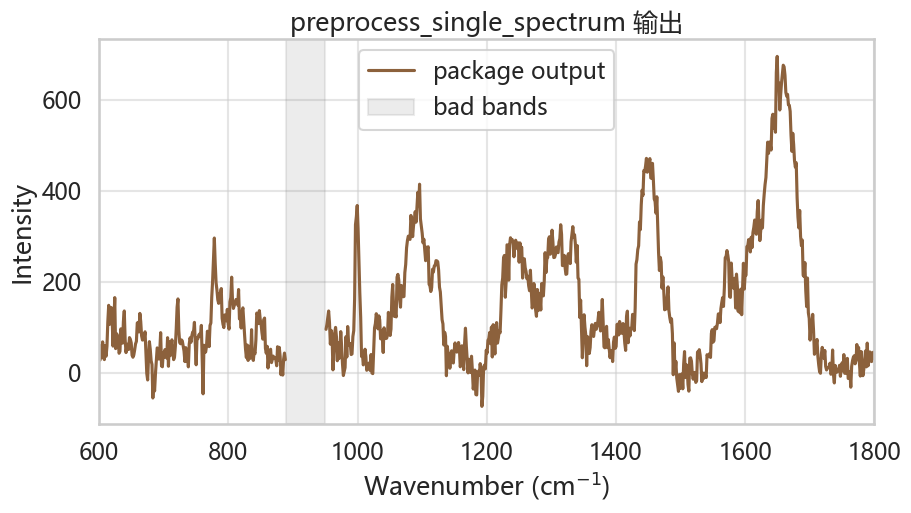

In [64]:
# 7. 直接调用库函数复核：应与上面的手工拆解结果一致
wn_pkg, sp_pkg, cosmic_pkg_replaced = preprocess_single_spectrum(
    wn,
    sp,
    cut_min=cfg.cut_min,
    cut_max=cfg.cut_max,
    wn_ref=WN_REF,
    bad_bands=BAD_BANDS,
    asls_lam=cfg.asls_lam,
    asls_p=cfg.asls_p,
    asls_max_iter=cfg.asls_max_iter,
    **COSMIC_RAY_OPTIONS,
)

if wn_pkg is None or sp_pkg is None:
    raise RuntimeError("preprocess_single_spectrum 返回空结果，通常是裁剪后有效点数不足")

print(f"wn 一致: {np.array_equal(wn_processed, wn_pkg)}")
print(f"sp 最大绝对误差: {np.max(np.abs(sp_processed - sp_pkg)):.6e}")
print(f"单谱宇宙射线替换点数一致: {cosmic_replaced == cosmic_pkg_replaced}")
print(f"库函数替换点数: {cosmic_pkg_replaced}")

fig, ax = plt.subplots()
plot_processed_with_mask(ax, wn_pkg, sp_pkg, color=sns.color_palette("muted")[5], label="package output")
ax.set_title("preprocess_single_spectrum 输出")
ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Intensity")
ax.legend()
plt.show()


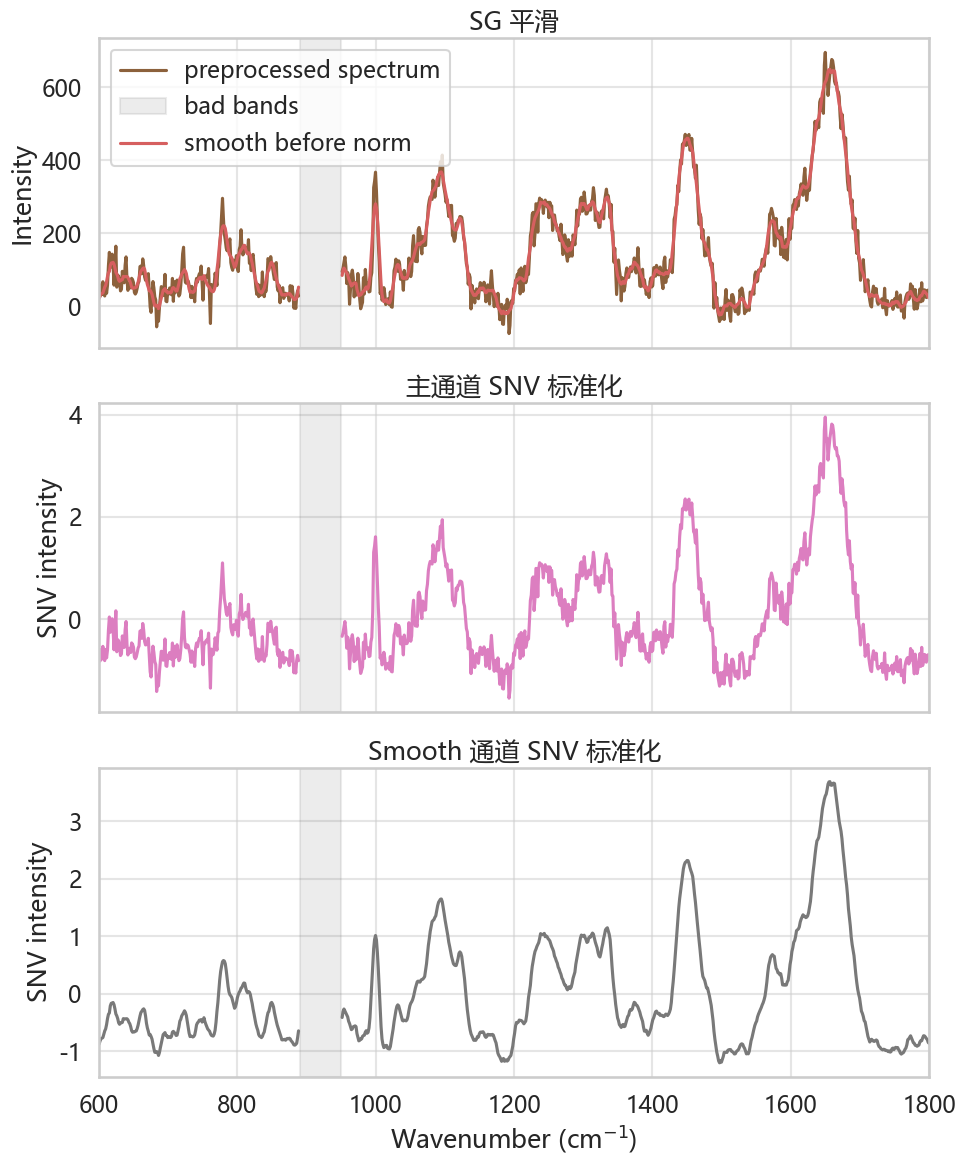

smooth 通道窗口: 15
smooth 通道多项式阶数: 3


In [65]:
# 8. smooth 通道展示：与 raman 中的 smooth 通道构建保持一致
# 当前 notebook 不做 raw 增强，因此这里等价于：预处理后主谱 -> SG smooth -> 当前标准化。
sg_smooth, _ = build_sg_kernels(train_cfg, torch.device("cpu"))
sp_pkg_tensor = torch.as_tensor(sp_pkg, dtype=torch.float32).view(1, 1, -1)
sp_smooth_pre_norm = F.conv1d(
    sp_pkg_tensor,
    sg_smooth,
    padding=train_cfg.win_smooth // 2,
)[0, 0].cpu().numpy()
sp_norm = normalize_spectrum(sp_pkg, train_cfg.norm_method)
sp_smooth = normalize_spectrum(sp_smooth_pre_norm, train_cfg.norm_method)

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
plot_processed_with_mask(axes[0], wn_pkg, sp_pkg, color=sns.color_palette("muted")[5], label="preprocessed spectrum")
plot_processed_with_mask(axes[0], wn_pkg, sp_smooth_pre_norm, color=sns.color_palette("muted")[3], label="smooth before norm")
axes[0].set_title("SG 平滑")
axes[0].set_ylabel("Intensity")
axes[0].legend()

plot_processed_with_mask(axes[1], wn_pkg, sp_norm, color=sns.color_palette("muted")[6])
axes[1].set_title(f"主通道 {train_cfg.norm_method.upper()} 标准化")
axes[1].set_ylabel(f"{train_cfg.norm_method.upper()} intensity")

plot_processed_with_mask(axes[2], wn_pkg, sp_smooth, color=sns.color_palette("muted")[7])
axes[2].set_title(f"Smooth 通道 {train_cfg.norm_method.upper()} 标准化")
axes[2].set_xlabel("Wavenumber (cm$^{-1}$)")
axes[2].set_ylabel(f"{train_cfg.norm_method.upper()} intensity")
plt.tight_layout()
plt.show()

print(f"smooth 通道窗口: {train_cfg.win_smooth}")
print("smooth 通道多项式阶数: 3")
